# Weather Prediction — Monitoring & Improving a Neural Network

This notebook is based on [episode 3](https://carpentries-lab.github.io/deep-learning-intro/3-monitor-the-model.html) and predicts tomorrow's sunshine hours in Basel using historical European weather data. It covers the full nine-step deep-learning workflow and introduces key techniques for **monitoring** and **reducing overfitting**: validation splits, early stopping, batch normalisation, and TensorBoard.

> **Platform:** Tested on **UCL's Unified AI Platform** (5 CPUs, 64 GB RAM). Runs in any standard environment with the required dependencies installed.

> **Support:** Contact [ARC.Collaborations@ucl.ac.uk](mailto:ARC.Collaborations@ucl.ac.uk) for help with AI platforms, GPUs, or Carpentries training.

---

| Shortcut | Action |
|---|---|
| `Shift + Enter` | Run current cell, move to next |
| `Alt + Enter` | Run current cell, insert new cell below |
| `Ctrl + Shift + F9` | Restart kernel and run all cells |

## 1. System Information

In [49]:
import sys, platform
from datetime import datetime

print(f"Date/Time : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python    : {sys.version}")
print(f"Platform  : {platform.platform()}")
print(f"Machine   : {platform.machine()}")

Date/Time : 2026-05-28 21:03:34
Python    : 3.11.10 | packaged by conda-forge | (main, Sep 30 2024, 18:08:57) [GCC 13.3.0]
Platform  : Linux-5.14.0-570.30.1.el9_6.x86_64-x86_64-with-glibc2.35
Machine   : x86_64


## 2. Imports

All imports are collected here. If an import fails, see the install cell at the bottom.

In [50]:
# Standard library
import time
import datetime
import os

# Data & visualisation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML / DL
import tensorflow
import tensorboard
import sklearn
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

print("All packages imported successfully.")

All packages imported successfully.


## Step 1. Formulate the Problem

> The [weather prediction dataset (light version)](https://zenodo.org/record/5071376) contains daily observations from 11 European cities over 2000–2010.

**Goal:** Predict tomorrow's sunshine hours in Basel from today's full weather record — a challenging regression task.

## Step 2. Identify Inputs and Outputs

In [51]:
DATA_URL = "https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1"
data = pd.read_csv(DATA_URL)
print(f"Shape: {data.shape}  ({data.shape[0]} days × {data.shape[1]} features)")
data.head()

Shape: (3654, 91)  (3654 days × 91 features)


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [52]:
print("Column names:")
data.columns.tolist()

Column names:


['DATE',
 'MONTH',
 'BASEL_cloud_cover',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'DE_BILT_cloud_cover',
 'DE_BILT_humidity',
 'DE_BILT_pressure',
 'DE_BILT_global_radiation',
 'DE_BILT_precipitation',
 'DE_BILT_sunshine',
 'DE_BILT_temp_mean',
 'DE_BILT_temp_min',
 'DE_BILT_temp_max',
 'DRESDEN_cloud_cover',
 'DRESDEN_humidity',
 'DRESDEN_global_radiation',
 'DRESDEN_precipitation',
 'DRESDEN_sunshine',
 'DRESDEN_temp_mean',
 'DRESDEN_temp_min',
 'DRESDEN_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max',
 'HEATHROW_cloud_cover',
 'HEATHROW_humidity',
 'HEATHROW_pressure',
 'HEATHROW_global_radiation',
 'HEATHROW_precipitation',
 'HEATHROW_sunshine',
 'HEATHROW_temp_mean'

In [53]:
# Use 3 years of data as our working slice
# For each row i, X = all feature columns (no DATE/MONTH)
# y = BASEL_sunshine from row i+1 (predicting *tomorrow*)
nr_rows = 365 * 3

X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")

X_data shape: (1096, 89)
y_data shape: (1096,)


## Step 3. Prepare Data

We create three splits:
- **Training (70 %)**: used to fit model weights.
- **Validation (15 %)**: monitored during training to detect overfitting.
- **Test (15 %)**: held out until final evaluation.

In [54]:
# First split: 70 % train, 30 % hold-out
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_data, y_data, test_size=0.3, random_state=0
)

# Second split: divide hold-out equally into val and test
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=0
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 767 samples
Val   : 164 samples
Test  : 165 samples


## Step 4. Define Model Architecture

We wrap the network definition in `create_nn()` so it is easy to rebuild a fresh model for each experiment.

In [55]:
keras.utils.set_random_seed(2)

def create_nn(input_shape, nodes1=100, nodes2=50):
    """Build a two-hidden-layer regression network.

    Args:
        input_shape: Tuple describing the input feature dimension.
        nodes1: Neurons in the first hidden layer (default 100).
        nodes2: Neurons in the second hidden layer (default 50).

    Returns:
        Uncompiled Keras Model.
    """
    inputs      = keras.Input(shape=input_shape, name='input')
    x           = keras.layers.Dense(units=nodes1, activation='relu')(inputs)
    x           = keras.layers.Dense(units=nodes2, activation='relu')(x)
    outputs     = keras.layers.Dense(units=1)(x)          # single regression output
    return keras.Model(inputs=inputs, outputs=outputs, name="weather_model")

model = create_nn(input_shape=(X_data.shape[1],))
model.summary()

Model: "weather_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,101 (55.08 KB)

 Trainable params: 14,101 (55.08 KB)

 Non-trainable params: 0 (0.00 B)

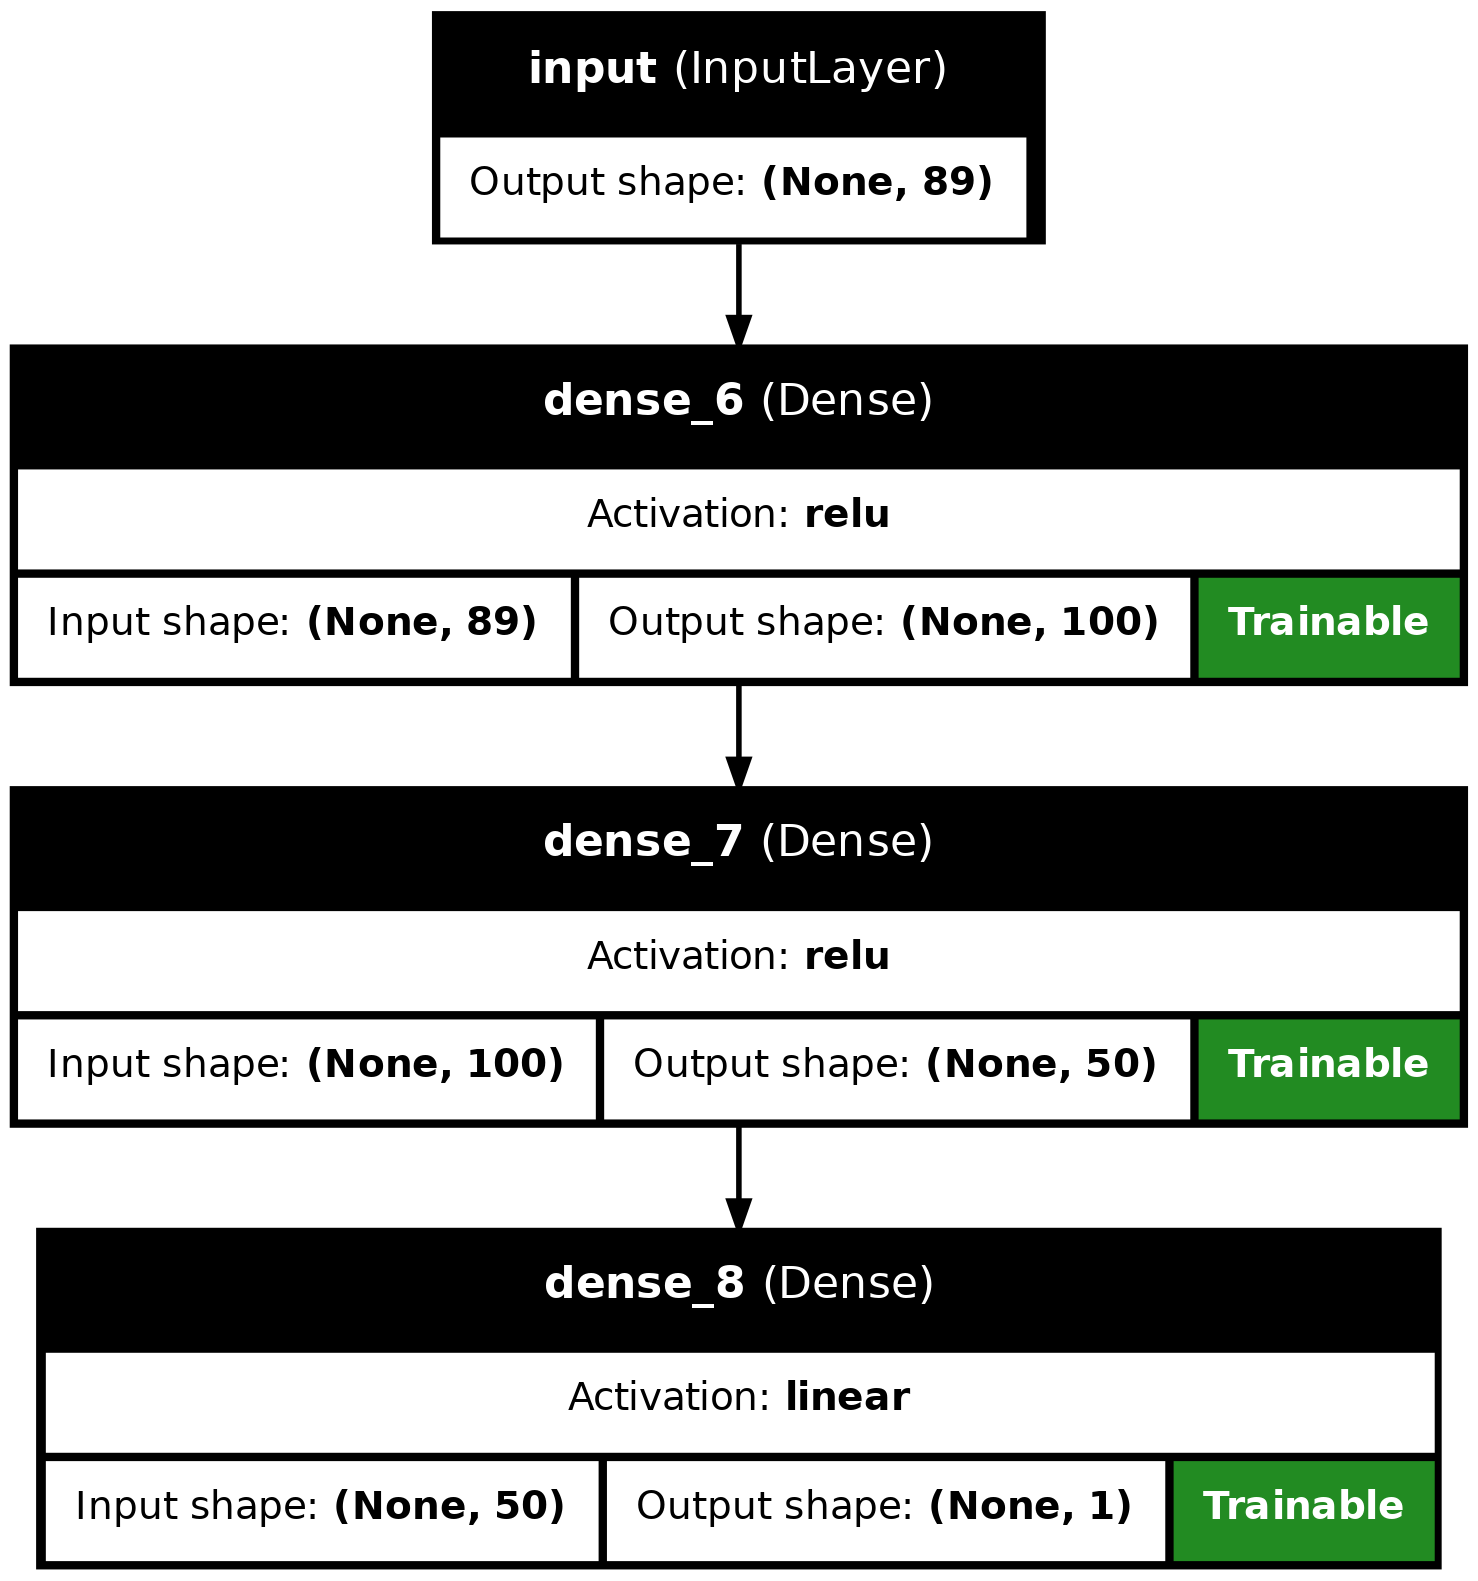

In [56]:
keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True,
)

## Step 5. Choose Loss Function & Optimiser

| Choice | Rationale |
|---|---|
| Loss: `mse` | Penalises large errors more than MAE, good for regression |
| Optimiser: `Adam` | Adaptive learning rate; robust default |
| Metric: `RMSE` | Same units as the target; more interpretable than MSE |

In [59]:
def compile_model(model):
    """Compile model with Adam + MSE loss + RMSE metric."""
    model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[keras.metrics.RootMeanSquaredError()]
    )

compile_model(model)

## Step 6. Train the Model

First pass: train on the training set only (no validation monitoring yet).

In [60]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    verbose=0   # set to 1 for per-epoch progress
)

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")

Training completed in 16.6s (0.28 min)


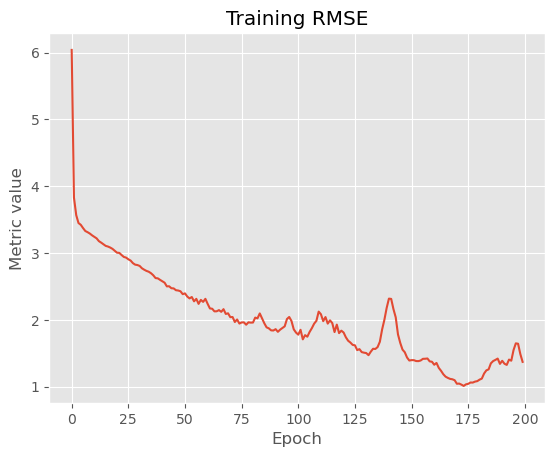

In [61]:
def plot_history(history, metrics):
    """Plot training (and optionally validation) metrics over epochs.

    Args:
        history: Keras History object returned by model.fit().
        metrics: Metric name (str) or list of metric names to plot.
    """
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("Epoch")
    plt.ylabel("Metric value")

plot_history(history, 'root_mean_squared_error')
plt.title("Training RMSE")
plt.show()

## Step 7. Make Predictions

In [62]:
y_train_predicted = model.predict(X_train)
y_test_predicted  = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


## Step 8. Measure Performance

For regression, scatter plots (predicted vs. true) are more informative than a single number.

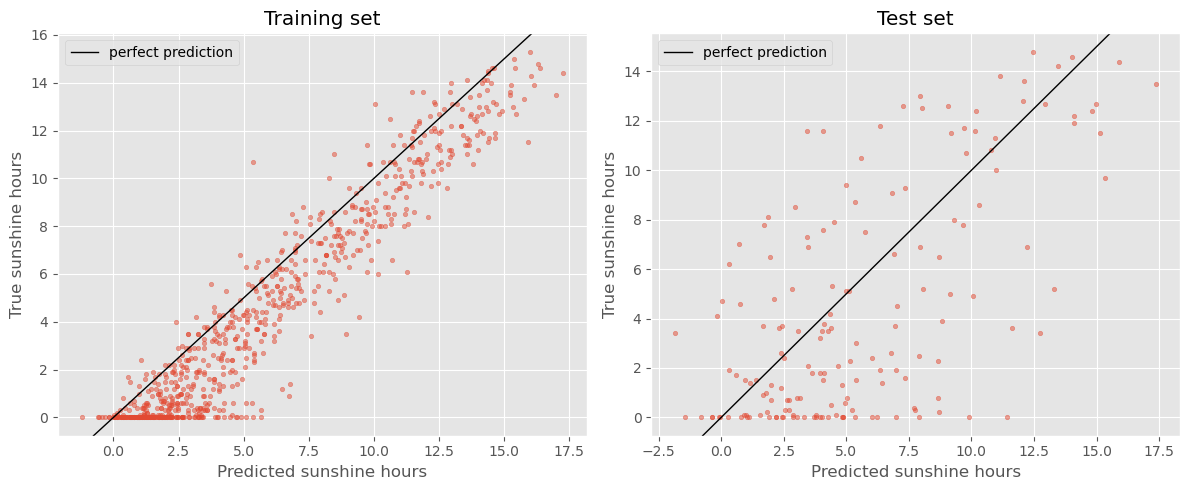

In [63]:
def plot_predictions(y_pred, y_true, title):
    """Scatter plot of predicted vs. true values with a diagonal reference line."""
    plt.style.use('ggplot')
    plt.scatter(y_pred, y_true, s=10, alpha=0.5)
    plt.axline((0, 0), slope=1, color="black", linewidth=1, label="perfect prediction")
    plt.xlabel("Predicted sunshine hours")
    plt.ylabel("True sunshine hours")
    plt.title(title)
    plt.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(axes[0]); plot_predictions(y_train_predicted, y_train, "Training set")
plt.sca(axes[1]); plot_predictions(y_test_predicted,  y_test,  "Test set")
plt.tight_layout()
plt.show()

In [64]:
train_metrics = model.evaluate(X_train, y_train, return_dict=True, verbose=0)
test_metrics  = model.evaluate(X_test,  y_test,  return_dict=True, verbose=0)
print(f"Train RMSE : {train_metrics['root_mean_squared_error']:.2f}")
print(f"Test  RMSE : {test_metrics['root_mean_squared_error']:.2f}")
print()
print("A large train–test gap indicates overfitting.")

Train RMSE : 1.83
Test  RMSE : 3.86

A large train–test gap indicates overfitting.


### Baseline: Predict Today's Value for Tomorrow

A simple but surprisingly competitive baseline: *tomorrow's sunshine = today's sunshine*. If our model cannot beat this, something is wrong.

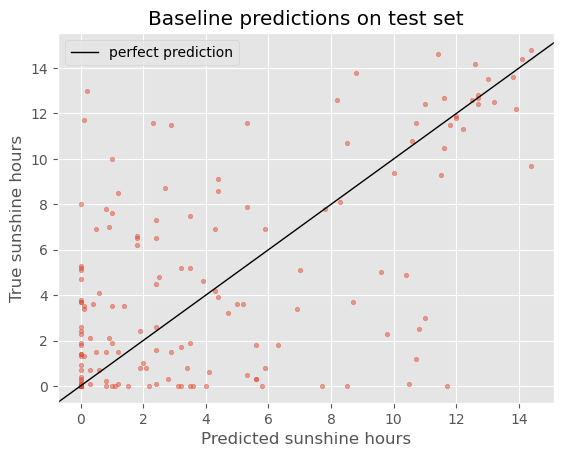

Baseline RMSE      : 3.88
Neural network RMSE: 3.86


In [65]:
y_baseline = X_test['BASEL_sunshine']
rmse_baseline = root_mean_squared_error(y_test, y_baseline)

plot_predictions(y_baseline, y_test, "Baseline predictions on test set")
plt.show()

print(f"Baseline RMSE      : {rmse_baseline:.2f}")
print(f"Neural network RMSE: {test_metrics['root_mean_squared_error']:.2f}")

## Step 9. Refine the Model

We progressively apply four improvements:
1. **Validation monitoring** — track generalisation during training.
2. **Smaller architecture** — reduce overfitting by cutting capacity.
3. **Early stopping** — stop training when validation loss stops improving.
4. **Batch normalisation** — normalise layer inputs for faster, more stable training.

### 9a. Add Validation Monitoring

Training completed in 29.6s


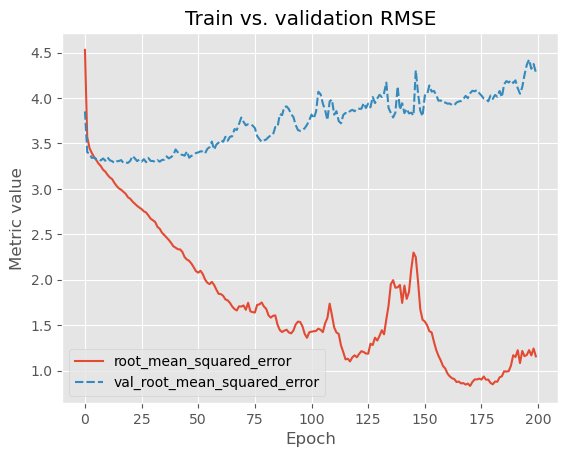

In [66]:
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_val, y_val),
    verbose=0
)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f}s")

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])
plt.title("Train vs. validation RMSE")
plt.show()

### 9b. Smaller Architecture

In [67]:
# Reduce from (100, 50) to (10, 5) neurons to lower model capacity
model_small = create_nn(input_shape=(X_data.shape[1],), nodes1=10, nodes2=5)
compile_model(model_small)
model_small.summary()

Model: "weather_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

Training completed in 29.1s


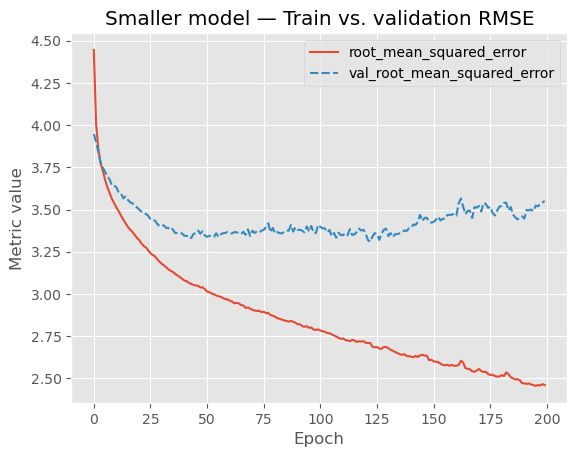

In [68]:
start_time = time.time()
history = model_small.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_val, y_val),
    verbose=0
)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f}s")

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])
plt.title("Smaller model — Train vs. validation RMSE")
plt.show()

### 9c. Early Stopping

Stopped at epoch 39 — completed in 6.4s


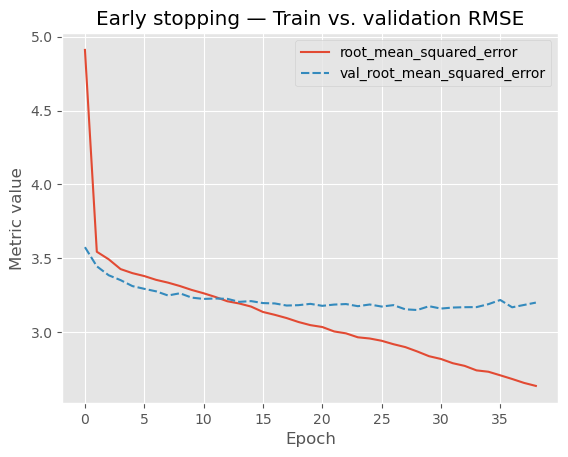

In [69]:
# EarlyStopping halts training when val_loss has not improved for `patience` epochs.
# This prevents wasted compute and acts as implicit regularisation.
earlystopper = EarlyStopping(monitor='val_loss', patience=10)

model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[earlystopper],
    verbose=0
)
elapsed = time.time() - start_time
print(f"Stopped at epoch {len(history.epoch)} — completed in {elapsed:.1f}s")

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])
plt.title("Early stopping — Train vs. validation RMSE")
plt.show()

### 9d. Batch Normalisation

In [71]:
# BatchNormalization normalises layer inputs to zero mean / unit variance per batch,
# which often allows higher learning rates and more stable training.
def create_nn_batchnorm(input_shape):
    inputs  = keras.Input(shape=input_shape, name='input')
    x       = keras.layers.BatchNormalization()(inputs)   # <-- new
    x       = keras.layers.Dense(units=100, activation='relu')(x)
    x       = keras.layers.Dense(units=50,  activation='relu')(x)
    outputs = keras.layers.Dense(units=1)(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="model_batchnorm")

model_bn = create_nn_batchnorm(input_shape=(X_data.shape[1],))
compile_model(model_bn)
model_bn.summary()

Model: "model_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89)             │           356 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,457 (56.47 KB)

 Trainable params: 14,279 (55.78 KB)

 Non-trainable params: 178 (712.00 B)

Stopped at epoch 10 — completed in 2.4s


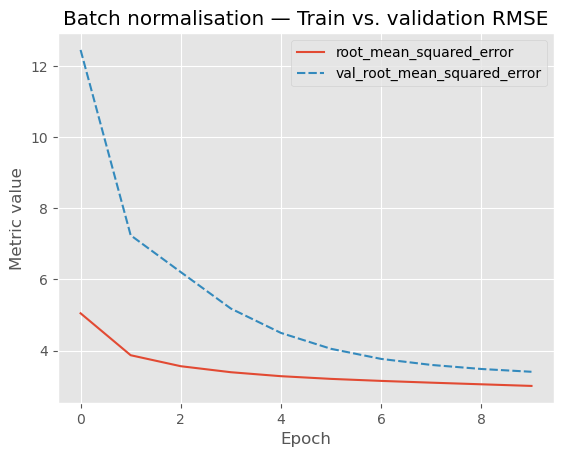

In [72]:
start_time = time.time()
history = model_bn.fit(
    X_train, y_train,
    batch_size=32,
    epochs=1000,
    validation_data=(X_val, y_val),
    callbacks=[earlystopper],
    verbose=0
)
elapsed = time.time() - start_time
print(f"Stopped at epoch {len(history.epoch)} — completed in {elapsed:.1f}s")

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])
plt.title("Batch normalisation — Train vs. validation RMSE")
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


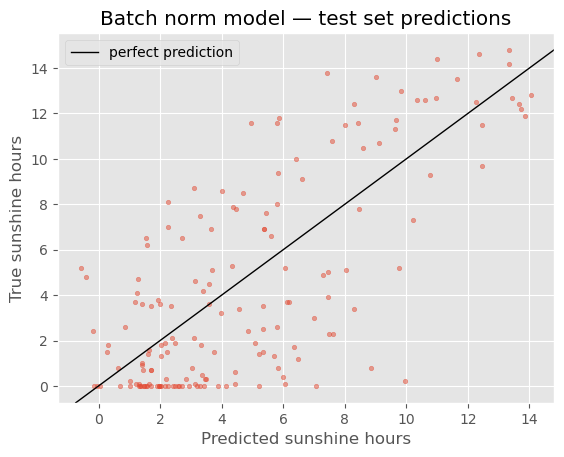

In [73]:
y_test_predicted = model_bn.predict(X_test)
plot_predictions(y_test_predicted, y_test, "Batch norm model — test set predictions")
plt.show()

### Exercise: Simplify and Add More Data

Restrict features to Basel-only columns and extend the training window to 9 years to see whether more data compensates for reduced feature richness.

In [74]:
# Extend to 9 years and restrict to Basel features only
nr_rows = 365 * 9
X_data_ext = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])
y_data_ext  = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

# Keep only Basel columns
basel_cols  = [c for c in X_data_ext.columns if c.startswith('BASEL')]
X_data_ext  = X_data_ext[basel_cols]
print(f"Extended dataset: {X_data_ext.shape}  (Basel features only)")

Extended dataset: (3286, 9)  (Basel features only)


In [75]:
X_train_ext, X_holdout_ext, y_train_ext, y_holdout_ext = train_test_split(
    X_data_ext, y_data_ext, test_size=0.3, random_state=0
)
X_val_ext, X_test_ext, y_val_ext, y_test_ext = train_test_split(
    X_holdout_ext, y_holdout_ext, test_size=0.5, random_state=0
)

model_ext = create_nn_batchnorm(input_shape=(X_data_ext.shape[1],))
compile_model(model_ext)
model_ext.summary()

Model: "model_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9)              │            36 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 100)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,137 (23.97 KB)

 Trainable params: 6,119 (23.90 KB)

 Non-trainable params: 18 (72.00 B)

Stopped at epoch 10 — completed in 2.9s


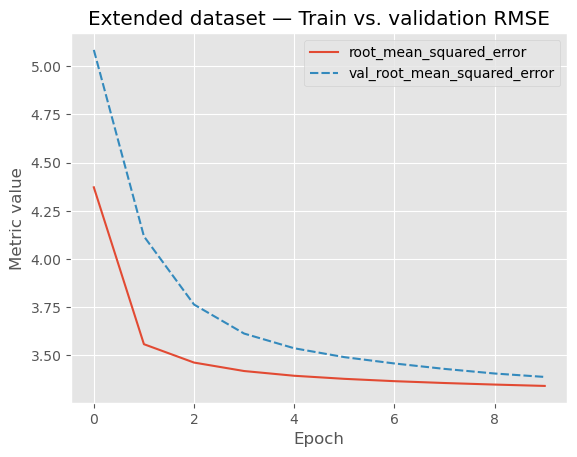

In [76]:
start_time = time.time()
history = model_ext.fit(
    X_train_ext, y_train_ext,
    batch_size=32,
    epochs=1000,
    validation_data=(X_val_ext, y_val_ext),
    callbacks=[earlystopper],
    verbose=0
)
elapsed = time.time() - start_time
print(f"Stopped at epoch {len(history.epoch)} — completed in {elapsed:.1f}s")

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])
plt.title("Extended dataset — Train vs. validation RMSE")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


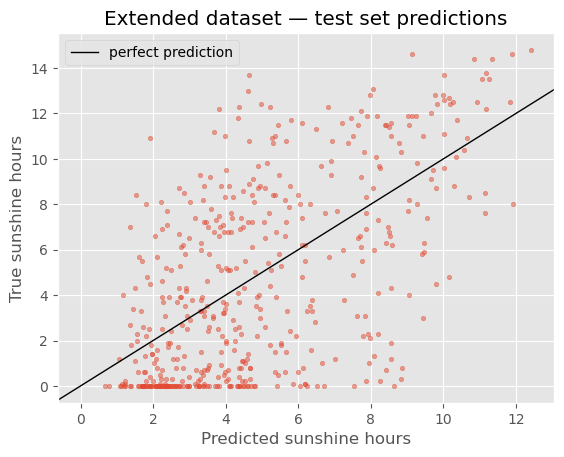

Test RMSE (extended): 3.40


In [77]:
y_test_pred_ext = model_ext.predict(X_test_ext)
plot_predictions(y_test_pred_ext, y_test_ext, "Extended dataset — test set predictions")
plt.show()

test_metrics_ext = model_ext.evaluate(X_test_ext, y_test_ext, return_dict=True, verbose=0)
print(f"Test RMSE (extended): {test_metrics_ext['root_mean_squared_error']:.2f}")

## 10. TensorBoard

TensorBoard provides interactive visualisation of training metrics, model graphs, and weight histograms. A timestamped log directory is created automatically each run.

In [78]:
# Ensure TensorBoard is on PATH (needed on some JupyterHub deployments)
import os
os.environ["PATH"] += ":/home/jovyan/.local/bin"

In [79]:
# Build the full dataset for the TensorBoard demo (use all available rows)
nr_rows_full = len(data) - 2
X_data_full  = data.loc[:nr_rows_full].drop(columns=['DATE', 'MONTH'])
y_data_full  = data.loc[1:(nr_rows_full + 1)]["BASEL_sunshine"]

X_train_tb, X_holdout_tb, y_train_tb, y_holdout_tb = train_test_split(
    X_data_full, y_data_full, test_size=0.3, random_state=0
)
X_val_tb, X_test_tb, y_val_tb, y_test_tb = train_test_split(
    X_holdout_tb, y_holdout_tb, test_size=0.5, random_state=0
)

In [80]:
# Each run writes to a uniquely timestamped subdirectory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
print(f"Logging to: {log_dir}")

Logging to: logs/fit/20260528-211119


In [81]:
model_tb = create_nn_batchnorm(input_shape=(X_data_full.shape[1],))
compile_model(model_tb)

start_time = time.time()
history = model_tb.fit(
    X_train_tb, y_train_tb,
    batch_size=32,
    epochs=200,
    validation_data=(X_val_tb, y_val_tb),
    callbacks=[tensorboard_callback],
    verbose=0
)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f}s")

Training completed in 57.8s


In [82]:
%load_ext tensorboard

In [83]:
# Launch TensorBoard in the notebook — uses the log_dir from above
%tensorboard --logdir {log_dir}

In [84]:
# %pip install --upgrade \
#     "tensorflow>=2.12.0" \
#     "scikit-learn>=1.2.2" \
#     "seaborn>=0.12.0"

## References

- Course: [Introduction to Deep Learning (Carpentries)](https://carpentries-lab.github.io/deep-learning-intro/)
- [Weather dataset on Zenodo](https://zenodo.org/record/5071376)
- [Keras training APIs](https://keras.io/api/models/model_training_apis/)
- [Keras callbacks — EarlyStopping](https://keras.io/api/callbacks/early_stopping/)
- [TensorBoard with Keras](https://www.tensorflow.org/tensorboard/get_started)